In [1]:
using Distributions
using StatsBase
using PythonPlot
using DataFrames
using Optim
using NLsolve
using Setfield
using CSV
using Turing
using LinearAlgebra
include("simulations.jl")
include("estimators.jl")
include("models.jl")
include("rem_theory.jl")

FIG_PATH = "/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/Finite Lineages Plos Journal/paper/figures"

"/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/Finite Lineages Plos Journal/paper/figures"

# setup

## Load data

In [2]:
# Read CSV file
data_raw = CSV.read("/Users/elevien/Downloads/data_processed.csv", DataFrame)

# Group and combine data with minimal operations

data = combine(groupby(data_raw, [:lineage, :cell]), 
               :time => first => :t, 
               :time => (x -> last(x) - first(x))=> :gt,
               :cell => first => :n,:gr => mean => :gr,:length=>first => :s0)

# Convert and normalize time in one step

data.gt= convert(Vector{Float64}, data.gt) ./ mean(data.gt);
data.t= (convert(Vector{Float64}, data.t) .-1) ./ mean(data.gt);

# add columns used in different models to dataframe
data[:,:y] = log.(data.s0) 
data[:,:ϕ] = log.(data.s0) ./ data.gt;


# Extract model paramaters

In [14]:

y = Matrix(data[data.lineage .== 2,[:ϕ,:gt]]);
L = length(y[:,1])
X = hcat(ones(L-1),y[1:L-1,:])
b = X\y[2:end,:]
b'*vcat(1,y[1,:])


2-element Vector{Float64}:
 0.859518264429244
 0.9151168748193891

In [15]:
function fitar(y)
    L = length(y[:,1])
    X = hcat(ones(L-1),y[1:L-1,:])
    b = X\y[2:end,:]
    v = mean((y[2:end,:] .- X*b).^2,dims=1)'
    return θ = (b = b,v = v)
end

function runar(y0,θ,n)
    n_vars = length(y0)
    yp = zeros((n,n_vars))
    yp[1,:] = y0
    for k in 2:n
        yp[k,:] = θ.b' * vcat(1,yp[k-1,:]) .+ rand(MvNormal(zeros(n_vars),diagm(θ.v[:,1])))
    end
    return yp
end

runar (generic function with 1 method)

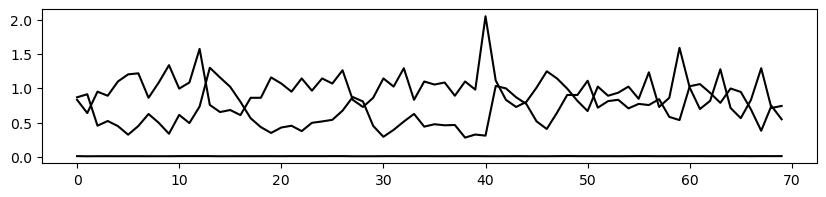

In [16]:
# WIP CODE FOR FITTING AUTOREGRESSIVE MODELS
y = Matrix(data[data.lineage .== 2,[:gt,:gr,:y]]);
θ_fit = fitar(y)
y_post = runar(y[1,:],fitar(y),length(y[:,1]))
y_post2 = runar(y[1,:],fitar(y_post),length(y[:,1]))
y_post3 = runar(y[1,:],fitar(y_post2),length(y[:,1]))

fig, ax= subplots(figsize=(10,2))
ax.plot(y,"k-")
#ax.plot(y_post,"C0.-")
#ax.plot(y_post2,"C1s-",markersize=2)
#ax.plot(y_post3,"C2+-")

fig

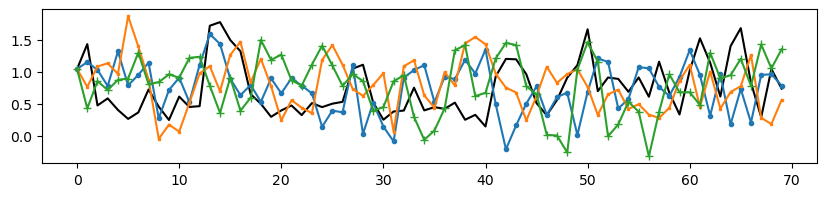

In [17]:
# WIP CODE FOR FITTING AUTOREGRESSIVE MODELS
y = Matrix(data[data.lineage .== 2,[:ϕ]]);
θ_fit = fitar(y)
y_post = runar(y[1,:],fitar(y),length(y[:,1]))
y_post2 = runar(y[1,:],fitar(y_post),length(y[:,1]))
y_post3 = runar(y[1,:],fitar(y_post2),length(y[:,1]))

fig, ax= subplots(figsize=(10,2))
ax.plot(y,"k-")
ax.plot(y_post,"C0.-")
ax.plot(y_post2,"C1s-",markersize=2)
ax.plot(y_post3,"C2+-")

fig

# Plot estimate vs. alpha

In [18]:
# need to make function that takes these as input, fits AR and returns data frame with t values needed to scaling 
labels = [:gt,:y,:gr] 

y = Matrix(data[data.lineage .== 2,[:gt,:y,:gr]]);
θ_fit = fitar(y)
yp = runar(y[1,:],θ_fit,170*length(y[:,1]))

11900×3 Matrix{Float64}:
 0.830714  0.867563  0.0110285
 0.634472  0.845032  0.0105305
 0.797457  0.654702  0.0103408
 1.38257   0.501756  0.0105093
 0.949781  0.749829  0.0103377
 0.752075  0.670036  0.0109916
 1.19402   0.63387   0.0100345
 0.788061  0.791218  0.0102923
 0.848992  0.657945  0.0108305
 1.06217   0.753291  0.0108971
 ⋮                   
 1.00916   0.995429  0.0102828
 0.449512  0.982171  0.0101874
 1.10062   0.641568  0.0103603
 1.09162   0.642232  0.0107581
 0.932501  0.689682  0.00928323
 0.87363   0.489915  0.0109726
 1.24741   0.446641  0.0110001
 1.43156   0.553117  0.0106742
 0.712175  1.04079   0.00987815

In [187]:
# generate scaling data
scaling = scalingdata_FDE(data,collect(1:2:60))
scaling_AR1 = scalingdata_FDE(dfAR1,collect(1:2:60));
scaling_CSC = scalingdata_FDE(dfCSC,collect(1:2:60));

In [188]:
# now I'm going to get the n and M values for the previous figure to compare
M_fig3 = 100
alpha_fig3 = CSV.read("./output/alpha_FDE",DataFrame)[:,1]
n_fig3 = alpha_fig3 .^2 .* M_fig3 ./ 2;

In [11]:



ms = 4
fig, ax= subplots(figsize=(5,3))

# ------------------------------------------------------------------------------------------
# INSET PLOT

axins = fig.add_axes([0.3, 0.6, 0.3, 0.3])
s = std(diff(data[1:20,:].t))
αc = βc/(log(2)*s) # our best approximation of αc

#axins.plot(scaling.α ,scaling.fde,"C5o",label=L"data",markersize=ms,fillstyle="none")
#axins.plot(scaling_AR1.α ,scaling_AR1.fde,"s",label=L"sims",markersize=ms)
axins.semilogx(scaling_sims.α ,scaling_CSC.fde,"+",label=L"sims (CSC)",markersize=ms)

Ltrue = 2log(2)/(1+sqrt(1-2log(2)*θ.σ^2))
# axins.plot([0,max(scaling.α ...)],ones(2) .*Ltrue,"--",label=L"$\hat{\Lambda}$ (sims)")

# axins.plot([0,max(scaling.α ...)] , log(2) ./ones(2)* 1 ,label=L"$\ln(2)/E[\tau]$")
# axins.set_xlabel(L"$\alpha$")
# axins.set_ylabel(L"$\hat{\Lambda}_{\rm FDE}$")
# axins.set_xlim([0,max(scaling.α ...)])

# ------------------------------------------------------------------------------------------
# MAIN PLOT 
ax.plot(scaling.α ,scaling.fde,"C5o",label=L"data",markersize=ms,fillstyle="none")

ax.semilogx(scaling_sims.α ,scaling_AR1.fde,"s",label=L"sims (AR1)",markersize=ms)
ax.semilogx(scaling_sims.α ,scaling_CSC.fde,"+",label=L"sims (CSC)",markersize=ms)
ax.vlines(αc,log(2),1.05*log(2),"C10",linestyle="-",label=L"$\alpha_c$ (sims)")
ax.plot([0,αc],ones(2) .*Ltrue,"--",label=L"$\hat{\Lambda}$ (sims)")

ax.plot([0,αc] , log(2) ./ones(2)* 1 ,label=L"$\ln(2)/E[\tau]$")
ax.legend(loc=1,facecolor="white",framealpha=1.0,edgecolor="w")

tight_layout()
savefig(FIG_PATH*"/data.pdf",bbox_inches="tight")
fig

UndefVarError: UndefVarError: `scaling_sims` not defined

In [7]:
fig, ax= subplots(figsize=(4,2))
ax.plot(scaling_sims.α ,scaling_sims.fde,"+-",label=L"$\hat{\Lambda}_{\rm FDE}$")
fig

UndefVarError: UndefVarError: `scaling_sims` not defined

\alpha  

# Check scaling of variance

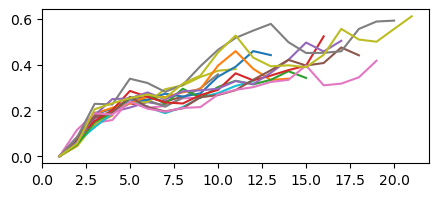

In [37]:
step = 500
data[:,:t_round] = round.(data.t / step) * step;

fig,ax = subplots(figsize=(5,2))

for g in 2:20
    # ------------------------------------------------------------
    Xg = grouplineages(data,g)
     
    v = combine(groupby(Xg,:n),:t => var => :v).v
    m = combine(groupby(Xg,:n),:t => mean => :m).m

    des = hcat(ones(length(m)),collect(1:length(m)))
    b = des\m
    y_fit = des*b 

    ax.plot(1:length(m),v,"-")
end
#
fig

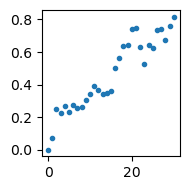

In [40]:
fig,ax = subplots(figsize=(2,2))
ax.plot(combine(groupby(grouplineages(data,30),:n),:t => var => :v).v,".")
tight_layout()
fig


It look slike the variance is not increasing linearly with time as we expect (show simulations in comparison)